# **1. Perkenalan Dataset**


# **Sentimen Analisis Ulasan Gojek di Google Play Store**

Nama : M Mahfudl Awaludin<br>
Email : mahfudawaludin.009@gmail.com

Selamat datang dalam proyek Sentimen Analisis Ulasan Gojek di Google Play Store! Dalam ekosistem dompet digital yang semakin berkembang, ulasan pengguna memainkan peran penting dalam membentuk persepsi dan pengalaman pengguna terhadap aplikasi tersebut. Proyek ini bertujuan untuk mengeksplorasi analisis sentimen guna memahami bagaimana pengguna merasakan dan mengungkapkan pendapat mereka tentang Gojek di Play Store.

**Apa itu Analisis Sentimen?**

Analisis sentimen adalah cabang dari pemrosesan bahasa alami (Natural Language Processing, NLP) yang digunakan untuk menganalisis teks dan mengidentifikasi apakah teks tersebut memiliki sentimen positif, negatif, atau netral. Dalam proyek ini, fokus analisis diarahkan pada ulasan pengguna Gojek, termasuk feedback, keluhan, serta pujian yang diberikan pengguna.

**Mengapa Analisis Sentimen untuk Gojek?**

Sebagai salah satu dompet digital paling populer di Indonesia, Gojek memiliki ribuan ulasan di Play Store. Dengan teknik analisis sentimen, pemahaman yang lebih mendalam dapat diperoleh mengenai:

1. Bagaimana pengguna merasakan pengalaman dalam menggunakan Gojek, termasuk kemudahan transaksi, cashback, atau promo yang ditawarkan.
2. Apa saja keluhan umum dari pengguna, seperti kendala top-up, keamanan akun, atau kegagalan transaksi.
3. Sejauh mana pembaruan aplikasi berdampak pada pengalaman pengguna, apakah memperbaiki atau justru menimbulkan masalah baru.

**Langkah-langkah Analisis Sentimen:**

1. Pengumpulan Data Ulasan:
  - Teknik web scraping digunakan untuk mengumpulkan ulasan pengguna Gojek dari Google Play Store.
  - Data yang diambil mencakup teks ulasan, rating (skor), serta metadata terkait lainnya.

2. Praktek Pengolahan Teks (Text Preprocessing):
Membersihkan teks ulasan dengan beberapa teknik, seperti:
  - Menghapus stopwords (kata-kata umum yang tidak memiliki makna penting seperti "dan", "di", "untuk").
  - Melakukan stemming atau lemmatization untuk menyederhanakan kata ke bentuk dasarnya.
  - Menghapus karakter khusus dan tanda baca yang tidak relevan.

3. Ekstraksi Fitur:
  - Teks ulasan yang telah dibersihkan akan dikonversi menjadi format numerik yang bisa dipahami oleh model machine learning, menggunakan teknik TF-IDF atau Word Embeddings.

4. Pelabelan Sentimen: Kita akan menggunakan skor ulasan (misalnya, 1-2 sebagai Negatif, 3 sebagai Netral, dan 4-5 sebagai Positif) untuk memberikan label sentimen pada setiap ulasan.

5. Pelatihan Model Machine Learning: Untuk memprediksi sentimen ulasan, kita akan menggunakan beberapa algoritma deep learning, seperti LSTM (Long Short-Term Memory) atau CNN (Convolutional Neural Networks), yang efektif untuk menangani data teks. Model ini akan dilatih menggunakan data ulasan yang telah dilabeli untuk mempelajari pola sentimen.

6. Evaluasi Model: Setelah model dilatih, kita akan mengevaluasi akurasi model pada testing set untuk memastikan bahwa model dapat memprediksi sentimen dengan baik. Target akurasi minimal untuk proyek ini adalah 85%.

7. Inferensi dan Prediksi: Setelah model siap, kita akan menggunakannya untuk memprediksi sentimen ulasan baru dan melihat apakah ulasan tersebut cenderung positif, negatif, atau netral.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
%pip install tqdm

from tqdm import tqdm
tqdm.pandas()

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [3]:
url = '/content/reviews_gojek.csv'
df = pd.read_csv(url)

# Menampilkan dataframe sebagai tabel
df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,9ab8279b-f217-4514-9ca6-0a8102ea6f45,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,baik sangat membantu sekali,5,0,5.13.1,2025-04-20 16:13:51,NaN,NaN,5.13.1
1,e9e37f46-0444-4a72-b377-fec0a7f580c1,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,halo pihak gojek saya mau daftar jadi gojek gi...,5,0,5.17.1,2025-04-20 16:02:20,NaN,NaN,5.17.1
2,f1232d63-700d-4b39-af95-a5ad0533b7a3,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mantap,5,0,NaN,2025-04-20 15:55:19,NaN,NaN,NaN
3,c5de759d-9397-4500-ac26-575f28cc4338,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"akun tiba2 tersuspen, pasti gara2 kasih bad re...",1,0,NaN,2025-04-20 15:55:15,"Hai, Kak Muhammad. Mohon maaf atas kendala yan...",2025-04-20 16:07:30,NaN
4,9c8d6711-ddda-4eb4-8ccb-5fdea198e02b,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mantap,1,0,NaN,2025-04-20 15:49:10,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
9995,4289f498-ba31-4e7b-a30b-6b573f901bf5,Ilalang Setiawan,https://play-lh.googleusercontent.com/a-/ALV-U...,Udah sejam nyari kurir ga nemu nemu,1,1,4.21.1,2025-02-28 16:27:30,"Mohon maaf atas ketidaknyamanannya, Kak Setiaw...",2025-03-01 07:40:51,4.21.1
9996,f70cf072-daac-4baf-9b24-1a90ef15711c,Aulia Indahwardhani,https://play-lh.googleusercontent.com/a-/ALV-U...,gojek sangat membantu apalagi gofood nya yang ...,4,11,5.12.1,2025-02-28 16:21:38,NaN,NaN,5.12.1
9997,bfc9ed23-051f-4c8a-916e-9ad30f9b3609,Riski Savitri,https://play-lh.googleusercontent.com/a-/ALV-U...,Makin parah ini aplikasi gofood nya. Sy udah n...,1,2,5.11.1,2025-02-28 16:20:17,"Hai Kak Riski, mohon maaf atas ketidaknyamanan...",2025-03-01 07:38:04,5.11.1
9998,9f76e2f2-20d6-4a7c-a928-a727c002fcd3,Fahrizal Husain,https://play-lh.googleusercontent.com/a/ACg8oc...,"Mesen gocar, dapet driver susah bener. Ada yan...",1,12,5.10.1,2025-02-28 16:10:16,"Hai Kak Fahrizal, mohon maaf atas ketidaknyama...",2025-03-01 07:32:14,5.10.1


In [4]:
# Menghitung dan menampilkan nilai NaN
missing_data = df.isna().sum()  # Menampilkan jumlah NaN per kolom
print(missing_data)

reviewId                   0
userName                   0
userImage                  0
content                    0
score                      0
thumbsUpCount              0
reviewCreatedVersion    2169
at                         0
replyContent            6484
repliedAt               6484
appVersion              2169
dtype: int64


In [5]:
# Tampilkan ringkasan dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              10000 non-null  object
 1   userName              10000 non-null  object
 2   userImage             10000 non-null  object
 3   content               10000 non-null  object
 4   score                 10000 non-null  int64 
 5   thumbsUpCount         10000 non-null  int64 
 6   reviewCreatedVersion  7831 non-null   object
 7   at                    10000 non-null  object
 8   replyContent          3516 non-null   object
 9   repliedAt             3516 non-null   object
 10  appVersion            7831 non-null   object
dtypes: int64(2), object(9)
memory usage: 859.5+ KB


In [6]:
# Hapus kolom pada DataFrame
df = df.drop(columns=['reviewId', 'userImage', 'thumbsUpCount', 'reviewCreatedVersion', 'replyContent',
                      'repliedAt', 'appVersion'])
print(df.columns)

Index(['userName', 'content', 'score', 'at'], dtype='object')


In [7]:
# Membuat DataFrame baru (clean_df) dengan menghapus baris yang memiliki nilai yang hilang (NaN) dari app_reviews_df
df = df.dropna()

In [8]:
# Tampilkan ringkasan dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   userName  10000 non-null  object
 1   content   10000 non-null  object
 2   score     10000 non-null  int64 
 3   at        10000 non-null  object
dtypes: int64(1), object(3)
memory usage: 312.6+ KB


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [9]:
# Hitung jumlah score pada rating 1 - 5
df['score'].value_counts()

,count
score,
5,5909
1,2834
4,492
2,395
3,370


<Axes: title={'center': 'Persebaran Data Score'}, xlabel='score'>

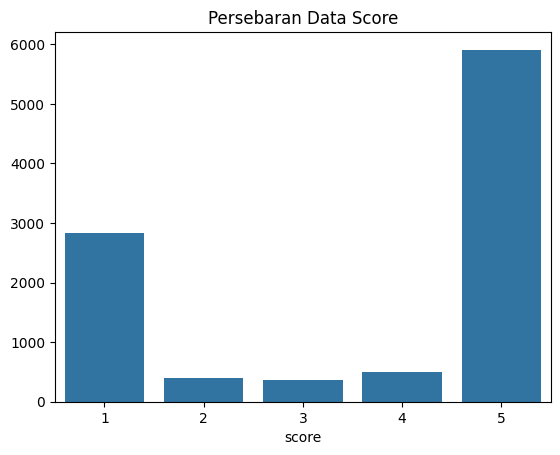

In [10]:
# Kelompokkan data berdasarkan kolom score
result = df.groupby(['score']).size()
plt.title('Persebaran Data Score')
sns.color_palette("viridis")
# plot the result
sns.barplot(x = result.index, y = result.values)

In [11]:
# Inisialisasi daftar sentimen
label_num = []

# Iterasi setiap baris dalam DataFrame
for index, row in df.iterrows():
    if row['score'] > 3 :
        label_num.append(1)     # nilai 1 untuk score 4 - 5
    elif row['score'] == 3:
        label_num.append(0)     # nilai 0 untuk score 3
    else:
        label_num.append(-1)    # nilai -1 untuk score 1 - 2

# Tambahkan kolom baru
df['label_num'] = label_num
df

,userName,content,score,at,label_num
0,Pengguna Google,baik sangat membantu sekali,5,2025-04-20 16:13:51,1
1,Pengguna Google,halo pihak gojek saya mau daftar jadi gojek gi...,5,2025-04-20 16:02:20,1
2,Pengguna Google,mantap,5,2025-04-20 15:55:19,1
3,Pengguna Google,"akun tiba2 tersuspen, pasti gara2 kasih bad re...",1,2025-04-20 15:55:15,-1
4,Pengguna Google,mantap,1,2025-04-20 15:49:10,-1
...,...,...,...,...,...
9995,Ilalang Setiawan,Udah sejam nyari kurir ga nemu nemu,1,2025-02-28 16:27:30,-1
9996,Aulia Indahwardhani,gojek sangat membantu apalagi gofood nya yang ...,4,2025-02-28 16:21:38,1
9997,Riski Savitri,Makin parah ini aplikasi gofood nya. Sy udah n...,1,2025-02-28 16:20:17,-1
9998,Fahrizal Husain,"Mesen gocar, dapet driver susah bener. Ada yan...",1,2025-02-28 16:10:16,-1


In [12]:
# Inisialisasi daftar label
label = []

# Iterasi setiap baris dalam DataFrame
for index, row in df.iterrows():
    if row['score'] > 3 :
        label.append("positive")     # nilai 1 untuk score 4 - 5
    elif row['score'] == 3:
        label.append("neutral")     # nilai 0 untuk score 3
    else:
        label.append("negative")    # nilai -1 untuk score 1 - 2

# Tambahkan kolom baru
df['label'] = label
df

,userName,content,score,at,label_num,label
0,Pengguna Google,baik sangat membantu sekali,5,2025-04-20 16:13:51,1,positive
1,Pengguna Google,halo pihak gojek saya mau daftar jadi gojek gi...,5,2025-04-20 16:02:20,1,positive
2,Pengguna Google,mantap,5,2025-04-20 15:55:19,1,positive
3,Pengguna Google,"akun tiba2 tersuspen, pasti gara2 kasih bad re...",1,2025-04-20 15:55:15,-1,negative
4,Pengguna Google,mantap,1,2025-04-20 15:49:10,-1,negative
...,...,...,...,...,...,...
9995,Ilalang Setiawan,Udah sejam nyari kurir ga nemu nemu,1,2025-02-28 16:27:30,-1,negative
9996,Aulia Indahwardhani,gojek sangat membantu apalagi gofood nya yang ...,4,2025-02-28 16:21:38,1,positive
9997,Riski Savitri,Makin parah ini aplikasi gofood nya. Sy udah n...,1,2025-02-28 16:20:17,-1,negative
9998,Fahrizal Husain,"Mesen gocar, dapet driver susah bener. Ada yan...",1,2025-02-28 16:10:16,-1,negative


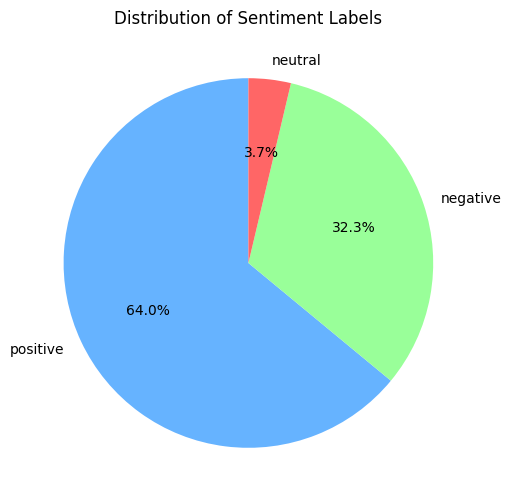

In [13]:
import matplotlib.pyplot as plt

# Hitung jumlah label pada setiap kategori
label_counts = df['label'].value_counts()

# Buat pie chart
plt.figure(figsize=(6, 6))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=90, colors=['#66b3ff', '#99ff99', '#ff6666'])
plt.title('Distribution of Sentiment Labels')
plt.show()

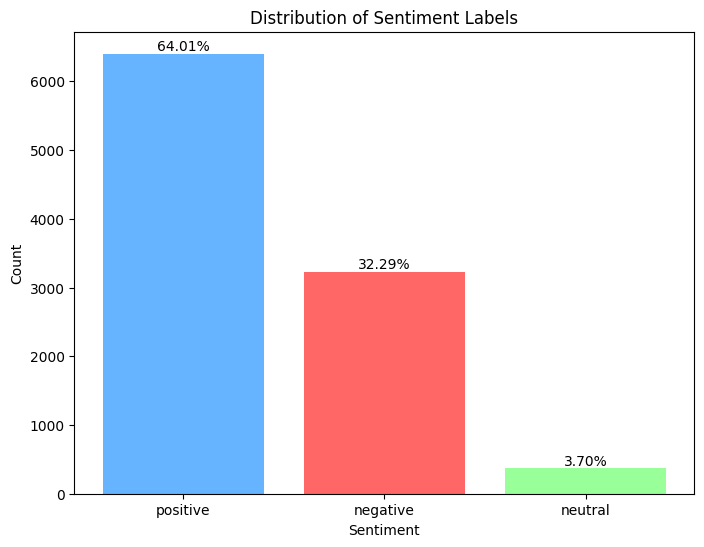

In [14]:
# Hitung jumlah label pada setiap kategori
label_counts = df['label'].value_counts()

# Hitung persentase untuk setiap kategori
label_percentages = label_counts / label_counts.sum() * 100

# Buat bar chart dan simpan dalam variabel `bars`
plt.figure(figsize=(8, 6))
bars = plt.bar(label_counts.index, label_counts.values, color=['#66b3ff', '#ff6666', '#99ff99'])

# Tambahkan persentase di atas setiap bar
for bar, percentage in zip(bars, label_percentages):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{percentage:.2f}%',
        ha='center',
        va='bottom'
    )

plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.title('Distribution of Sentiment Labels')
plt.show()

### Preprocessing Text

**Proses Pembersihan Teks (Text Preprocessing)**

Kode ini mengimpor pustaka yang diperlukan seperti nltk, re, string, dan pandas, serta mengunduh resource nltk seperti punkt, stopwords, dan wordnet untuk mendukung analisis teks. Fungsi preprocess_text() digunakan untuk membersihkan teks dengan menghapus URL, mention, hashtag, dan karakter khusus, serta mengonversinya menjadi huruf kecil. Selain itu, fungsi ini juga menghapus tanda baca dan spasi berlebih agar teks lebih bersih dan siap untuk diproses lebih lanjut. Fungsi ini kemudian diterapkan ke kolom 'content' dalam dataframe df, menghasilkan kolom baru 'text_Clean' yang berisi teks yang telah diproses.

In [15]:
%pip install nltk

In [16]:
import string
import nltk
import re

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [17]:
import pandas as pd
import re # modul re adalah regular expression

def preprocess_text(text):
    # Menghapus URL
    text = re.sub(r'https\S+', ' ', text, flags=re.IGNORECASE)

    # Mengubah teks jadi lower case
    text = text.lower()

    # Menghapus mention
    text = re.sub(r'@\S+', ' ', text, flags=re.IGNORECASE)

    # Menghapus hashtag
    text = re.sub(r'#\S+', ' ', text, flags=re.IGNORECASE)

    # Menghapus next karakter
    text = re.sub(r"'\w+", ' ', text)

    # Menghapus tanda baca
    text = re.sub(r'[^\w\s]', ' ', text)

    # Menghapus extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Terapkan fungsi preprocess_text ke kolom 'content'
df['text_Clean'] = df['content'].progress_apply(preprocess_text)
df

100%|██████████| 10000/10000 [00:00<00:00, 32360.64it/s]


,userName,content,score,at,label_num,label,text_Clean
0,Pengguna Google,baik sangat membantu sekali,5,2025-04-20 16:13:51,1,positive,baik sangat membantu sekali
1,Pengguna Google,halo pihak gojek saya mau daftar jadi gojek gi...,5,2025-04-20 16:02:20,1,positive,halo pihak gojek saya mau daftar jadi gojek gi...
2,Pengguna Google,mantap,5,2025-04-20 15:55:19,1,positive,mantap
3,Pengguna Google,"akun tiba2 tersuspen, pasti gara2 kasih bad re...",1,2025-04-20 15:55:15,-1,negative,akun tiba2 tersuspen pasti gara2 kasih bad rev...
4,Pengguna Google,mantap,1,2025-04-20 15:49:10,-1,negative,mantap
...,...,...,...,...,...,...,...
9995,Ilalang Setiawan,Udah sejam nyari kurir ga nemu nemu,1,2025-02-28 16:27:30,-1,negative,udah sejam nyari kurir ga nemu nemu
9996,Aulia Indahwardhani,gojek sangat membantu apalagi gofood nya yang ...,4,2025-02-28 16:21:38,1,positive,gojek sangat membantu apalagi gofood nya yang ...
9997,Riski Savitri,Makin parah ini aplikasi gofood nya. Sy udah n...,1,2025-02-28 16:20:17,-1,negative,makin parah ini aplikasi gofood nya sy udah nu...
9998,Fahrizal Husain,"Mesen gocar, dapet driver susah bener. Ada yan...",1,2025-02-28 16:10:16,-1,negative,mesen gocar dapet driver susah bener ada yang ...


**Proses Normalisasi Teks dengan Kamus Slang**

Kode ini membaca kamus slang dari file Excel 'kamuskatabaku.xlsx' dan menyusunnya dalam bentuk dictionary dengan pasangan kata tidak baku sebagai kunci dan kata baku sebagai nilai. Fungsi ganti_slang() dibuat untuk menggantikan kata-kata slang dalam teks dengan padanan kata baku berdasarkan kamus yang telah disusun. Fungsi ini kemudian diterapkan pada kolom 'text_Clean' dalam dataframe df, menghasilkan kolom baru 'text_Normalization' yang berisi teks yang telah dinormalisasi dengan kata baku.

In [21]:
# Kamus slang Bahasa Indonesia: kata tidak baku -> kata baku
slang_dict = {
    "yg": "yang",
    "dgn": "dengan",
    "dg": "dengan",
    "tdk": "tidak",
    "gak": "tidak",
    "ga": "tidak",
    "gk": "tidak",
    "nggak": "tidak",
    "ngga": "tidak",
    "kagak": "tidak",
    "udah": "sudah",
    "udh": "sudah",
    "sudah": "sudah",
    "blm": "belum",
    "belom": "belum",
    "bgt": "banget",
    "banget": "banget",
    "aja": "saja",
    "aj": "saja",
    "doang": "saja",
    "kalo": "kalau",
    "klo": "kalau",
    "klu": "kalau",
    "krn": "karena",
    "karna": "karena",
    "dpt": "dapat",
    "dapet": "dapat",
    "bisa": "bisa",
    "gimana": "bagaimana",
    "gmn": "bagaimana",
    "kenapa": "mengapa",
    "knp": "mengapa",
    "dimana": "di mana",
    "dmn": "di mana",
    "disini": "di sini",
    "dsini": "di sini",
    "disana": "di sana",
    "bs": "bisa",
    "hrs": "harus",
    "harus": "harus",
    "sm": "sama",
    "sama": "sama",
    "sbg": "sebagai",
    "utk": "untuk",
    "untuk": "untuk",
    "pd": "pada",
    "dr": "dari",
    "dari": "dari",
    "ke": "ke",
    "aja": "saja",
    "tau": "tahu",
    "tahu": "tahu",
    "pengen": "ingin",
    "pgn": "ingin",
    "mau": "mau",
    "ngerti": "mengerti",
    "ngert": "mengerti",
    "gitu": "begitu",
    "gtu": "begitu",
    "gini": "begini",
    "gni": "begini",
    "emang": "memang",
    "emg": "memang",
    "bener": "benar",
    "bnr": "benar",
    "kayak": "seperti",
    "kaya": "seperti",
    "kek": "seperti",
    "temen": "teman",
    "tmn": "teman",
    "orang": "orang",
    "org": "orang",
    "makasih": "terima kasih",
    "mksh": "terima kasih",
    "thanks": "terima kasih",
    "thx": "terima kasih",
    "pls": "tolong",
    "plis": "tolong",
    "tolong": "tolong",
    "sorry": "maaf",
    "sori": "maaf",
    "maaf": "maaf",
    "lg": "lagi",
    "lagi": "lagi",
    "lagi2": "lagi-lagi",
    "dah": "sudah",
    "trus": "terus",
    "trs": "terus",
    "terus": "terus",
    "jd": "jadi",
    "jdi": "jadi",
    "jadi": "jadi",
    "kamu": "kamu",
    "km": "kamu",
    "aku": "aku",
    "aq": "aku",
    "gw": "saya",
    "gue": "saya",
    "gua": "saya",
    "lu": "kamu",
    "loe": "kamu",
    "elo": "kamu",
    "dia": "dia",
    "mereka": "mereka",
    "bkn": "bukan",
    "bukan": "bukan",
    "spt": "seperti",
    "seperti": "seperti",
    "dri": "dari",
    "dgn": "dengan",
    "sbnrnya": "sebenarnya",
    "sebenernya": "sebenarnya",
    "sebenarnya": "sebenarnya",
    "kayaknya": "sepertinya",
    "kyknya": "sepertinya",
    "mungkin": "mungkin",
    "mgkn": "mungkin",
    "masih": "masih",
    "msih": "masih",
    "sbg": "sebagai",
    "bwt": "buat",
    "buat": "buat",
    "pdhl": "padahal",
    "padahal": "padahal",
    "cuma": "hanya",
    "cm": "hanya",
    "tp": "tetapi",
    "tapi": "tetapi",
    "tpi": "tetapi",
    "karena": "karena",
    "soalnya": "karena",
    "soalny": "karena",
}

In [22]:
# ============================================================
# Fungsi mengganti slang menjadi kata baku
# ============================================================
def ganti_slang(teks):
    def replace_word(match):
        kata = match.group(0)
        return slang_dict.get(kata.lower(), kata)

    return re.sub(r'\b[\w]+\b', replace_word, str(teks))


# ============================================================
# Contoh penggunaan
# ============================================================
teks = "aku lg makan, enak bgt! makasih ya."

hasil = ganti_slang(teks)

print("Sebelum :", teks)
print("Sesudah :", hasil)

Sebelum : aku lg makan, enak bgt! makasih ya.
Sesudah : aku lagi makan, enak banget! terima kasih ya.


In [24]:
# Menerapkan fungsi ganti_slang pada kolom 'text_StopWord'
df['text_Normalization'] = df['text_Clean'].progress_apply(ganti_slang)
df

100%|██████████| 10000/10000 [00:00<00:00, 95506.55it/s]


,userName,content,score,at,label_num,label,text_Clean,text_Normalization
0,Pengguna Google,baik sangat membantu sekali,5,2025-04-20 16:13:51,1,positive,baik sangat membantu sekali,baik sangat membantu sekali
1,Pengguna Google,halo pihak gojek saya mau daftar jadi gojek gi...,5,2025-04-20 16:02:20,1,positive,halo pihak gojek saya mau daftar jadi gojek gi...,halo pihak gojek saya mau daftar jadi gojek ba...
2,Pengguna Google,mantap,5,2025-04-20 15:55:19,1,positive,mantap,mantap
3,Pengguna Google,"akun tiba2 tersuspen, pasti gara2 kasih bad re...",1,2025-04-20 15:55:15,-1,negative,akun tiba2 tersuspen pasti gara2 kasih bad rev...,akun tiba2 tersuspen pasti gara2 kasih bad rev...
4,Pengguna Google,mantap,1,2025-04-20 15:49:10,-1,negative,mantap,mantap
...,...,...,...,...,...,...,...,...
9995,Ilalang Setiawan,Udah sejam nyari kurir ga nemu nemu,1,2025-02-28 16:27:30,-1,negative,udah sejam nyari kurir ga nemu nemu,sudah sejam nyari kurir tidak nemu nemu
9996,Aulia Indahwardhani,gojek sangat membantu apalagi gofood nya yang ...,4,2025-02-28 16:21:38,1,positive,gojek sangat membantu apalagi gofood nya yang ...,gojek sangat membantu apalagi gofood nya yang ...
9997,Riski Savitri,Makin parah ini aplikasi gofood nya. Sy udah n...,1,2025-02-28 16:20:17,-1,negative,makin parah ini aplikasi gofood nya sy udah nu...,makin parah ini aplikasi gofood nya sy sudah n...
9998,Fahrizal Husain,"Mesen gocar, dapet driver susah bener. Ada yan...",1,2025-02-28 16:10:16,-1,negative,mesen gocar dapet driver susah bener ada yang ...,mesen gocar dapat driver susah benar ada yang ...


**Proses Penghapusan Kata Umum (Stopword Removal)**

Kode ini menggunakan pustaka nltk untuk mengunduh dan mengimpor daftar stopwords dalam bahasa Indonesia. Stopwords adalah kata-kata umum yang sering muncul dalam teks tetapi tidak memiliki makna signifikan dalam analisis, seperti "dan", "di", "ke". Fungsi ini menerapkan filter pada kolom 'text_Normalization' untuk menghapus stopwords, menghasilkan kolom baru 'text_StopWord' yang berisi teks yang lebih bersih dan lebih relevan untuk analisis lebih lanjut.

In [25]:
# Import pustaka nltk dari modul corpus
import nltk.corpus
nltk.download('stopwords') # download stopwords
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [26]:
# Hapus kata - kata umum
stop = stopwords.words('indonesian')
df['text_StopWord'] = df['text_Normalization'].progress_apply(lambda x:' '.join([word for word in x.split() if word not in (stop)]))
df

100%|██████████| 10000/10000 [00:00<00:00, 14099.47it/s]


,userName,content,score,at,label_num,label,text_Clean,text_Normalization,text_StopWord
0,Pengguna Google,baik sangat membantu sekali,5,2025-04-20 16:13:51,1,positive,baik sangat membantu sekali,baik sangat membantu sekali,membantu
1,Pengguna Google,halo pihak gojek saya mau daftar jadi gojek gi...,5,2025-04-20 16:02:20,1,positive,halo pihak gojek saya mau daftar jadi gojek gi...,halo pihak gojek saya mau daftar jadi gojek ba...,halo gojek daftar gojek ya kerja tolong respon...
2,Pengguna Google,mantap,5,2025-04-20 15:55:19,1,positive,mantap,mantap,mantap
3,Pengguna Google,"akun tiba2 tersuspen, pasti gara2 kasih bad re...",1,2025-04-20 15:55:15,-1,negative,akun tiba2 tersuspen pasti gara2 kasih bad rev...,akun tiba2 tersuspen pasti gara2 kasih bad rev...,akun tiba2 tersuspen gara2 kasih bad review dr...
4,Pengguna Google,mantap,1,2025-04-20 15:49:10,-1,negative,mantap,mantap,mantap
...,...,...,...,...,...,...,...,...,...
9995,Ilalang Setiawan,Udah sejam nyari kurir ga nemu nemu,1,2025-02-28 16:27:30,-1,negative,udah sejam nyari kurir ga nemu nemu,sudah sejam nyari kurir tidak nemu nemu,sejam nyari kurir nemu nemu
9996,Aulia Indahwardhani,gojek sangat membantu apalagi gofood nya yang ...,4,2025-02-28 16:21:38,1,positive,gojek sangat membantu apalagi gofood nya yang ...,gojek sangat membantu apalagi gofood nya yang ...,gojek membantu gofood nya mempermudah membeli ...
9997,Riski Savitri,Makin parah ini aplikasi gofood nya. Sy udah n...,1,2025-02-28 16:20:17,-1,negative,makin parah ini aplikasi gofood nya sy udah nu...,makin parah ini aplikasi gofood nya sy sudah n...,parah aplikasi gofood nya sy nunggu sampe 3 ja...
9998,Fahrizal Husain,"Mesen gocar, dapet driver susah bener. Ada yan...",1,2025-02-28 16:10:16,-1,negative,mesen gocar dapet driver susah bener ada yang ...,mesen gocar dapat driver susah benar ada yang ...,mesen gocar driver susah digantung orderannya ...


**Proses Tokenisasi Teks (Text Tokenization)**

Dalam tahap ini, kode menggunakan metode RegexpTokenizer dari pustaka nltk untuk melakukan tokenisasi teks, yaitu memecah teks menjadi kata-kata individual (tokens). Tokenisasi dilakukan pada kolom 'text_StopWord', yang sebelumnya telah dibersihkan dari stopwords. Hasilnya disimpan dalam kolom baru 'text_Tokenization', di mana setiap ulasan diubah menjadi daftar kata-kata terpisah, sehingga lebih mudah untuk diproses dalam analisis lebih lanjut.

In [27]:
# impor word_tokenize dari modul nltk
from nltk.tokenize import sent_tokenize, word_tokenize

In [28]:
# Melakukan tokenize menggunakan Regexp
from nltk.tokenize import RegexpTokenizer
regexp = RegexpTokenizer('\w+')
df['text_Tokenization']=df['text_StopWord'].progress_apply(regexp.tokenize)
df

<>:3: SyntaxWarning: invalid escape sequence '\w'
<>:3: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipykernel_630/899065620.py:3: SyntaxWarning: invalid escape sequence '\w'
  regexp = RegexpTokenizer('\w+')
100%|██████████| 10000/10000 [00:00<00:00, 240623.26it/s]


,userName,content,score,at,label_num,label,text_Clean,text_Normalization,text_StopWord,text_Tokenization
0,Pengguna Google,baik sangat membantu sekali,5,2025-04-20 16:13:51,1,positive,baik sangat membantu sekali,baik sangat membantu sekali,membantu,[membantu]
1,Pengguna Google,halo pihak gojek saya mau daftar jadi gojek gi...,5,2025-04-20 16:02:20,1,positive,halo pihak gojek saya mau daftar jadi gojek gi...,halo pihak gojek saya mau daftar jadi gojek ba...,halo gojek daftar gojek ya kerja tolong respon...,"[halo, gojek, daftar, gojek, ya, kerja, tolong..."
2,Pengguna Google,mantap,5,2025-04-20 15:55:19,1,positive,mantap,mantap,mantap,[mantap]
3,Pengguna Google,"akun tiba2 tersuspen, pasti gara2 kasih bad re...",1,2025-04-20 15:55:15,-1,negative,akun tiba2 tersuspen pasti gara2 kasih bad rev...,akun tiba2 tersuspen pasti gara2 kasih bad rev...,akun tiba2 tersuspen gara2 kasih bad review dr...,"[akun, tiba2, tersuspen, gara2, kasih, bad, re..."
4,Pengguna Google,mantap,1,2025-04-20 15:49:10,-1,negative,mantap,mantap,mantap,[mantap]
...,...,...,...,...,...,...,...,...,...,...
9995,Ilalang Setiawan,Udah sejam nyari kurir ga nemu nemu,1,2025-02-28 16:27:30,-1,negative,udah sejam nyari kurir ga nemu nemu,sudah sejam nyari kurir tidak nemu nemu,sejam nyari kurir nemu nemu,"[sejam, nyari, kurir, nemu, nemu]"
9996,Aulia Indahwardhani,gojek sangat membantu apalagi gofood nya yang ...,4,2025-02-28 16:21:38,1,positive,gojek sangat membantu apalagi gofood nya yang ...,gojek sangat membantu apalagi gofood nya yang ...,gojek membantu gofood nya mempermudah membeli ...,"[gojek, membantu, gofood, nya, mempermudah, me..."
9997,Riski Savitri,Makin parah ini aplikasi gofood nya. Sy udah n...,1,2025-02-28 16:20:17,-1,negative,makin parah ini aplikasi gofood nya sy udah nu...,makin parah ini aplikasi gofood nya sy sudah n...,parah aplikasi gofood nya sy nunggu sampe 3 ja...,"[parah, aplikasi, gofood, nya, sy, nunggu, sam..."
9998,Fahrizal Husain,"Mesen gocar, dapet driver susah bener. Ada yan...",1,2025-02-28 16:10:16,-1,negative,mesen gocar dapet driver susah bener ada yang ...,mesen gocar dapat driver susah benar ada yang ...,mesen gocar driver susah digantung orderannya ...,"[mesen, gocar, driver, susah, digantung, order..."


**Proses Stemming (Stemming Teks)**

Pada tahap ini, kode menggunakan pustaka Sastrawi untuk melakukan stemming, yaitu proses mengubah kata berimbuhan menjadi bentuk dasarnya. Dengan menggunakan StemmerFactory dari Sastrawi, setiap kata dalam kolom 'text_Tokenization' diproses agar kembali ke akar katanya. Hasil stemming ini disimpan dalam kolom 'text_Stemmindo', yang nantinya dapat digunakan untuk analisis lebih lanjut, seperti klasifikasi sentimen atau pemodelan teks lainnya.

In [29]:
%pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 8.2 MB/s eta 0:00:00


In [30]:
# import Sastrawi package
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# create stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

In [31]:
# Melakukan stemming dari tokens
df['text_Stemmindo'] = df['text_Tokenization'].progress_apply(lambda x: [stemmer.stem(y) for y in x])

100%|██████████| 10000/10000 [12:18<00:00, 13.55it/s]


In [32]:
# Tampilkan DataFrame
df

,userName,content,score,at,label_num,label,text_Clean,text_Normalization,text_StopWord,text_Tokenization,text_Stemmindo
0,Pengguna Google,baik sangat membantu sekali,5,2025-04-20 16:13:51,1,positive,baik sangat membantu sekali,baik sangat membantu sekali,membantu,[membantu],[bantu]
1,Pengguna Google,halo pihak gojek saya mau daftar jadi gojek gi...,5,2025-04-20 16:02:20,1,positive,halo pihak gojek saya mau daftar jadi gojek gi...,halo pihak gojek saya mau daftar jadi gojek ba...,halo gojek daftar gojek ya kerja tolong respon...,"[halo, gojek, daftar, gojek, ya, kerja, tolong...","[halo, gojek, daftar, gojek, ya, kerja, tolong..."
2,Pengguna Google,mantap,5,2025-04-20 15:55:19,1,positive,mantap,mantap,mantap,[mantap],[mantap]
3,Pengguna Google,"akun tiba2 tersuspen, pasti gara2 kasih bad re...",1,2025-04-20 15:55:15,-1,negative,akun tiba2 tersuspen pasti gara2 kasih bad rev...,akun tiba2 tersuspen pasti gara2 kasih bad rev...,akun tiba2 tersuspen gara2 kasih bad review dr...,"[akun, tiba2, tersuspen, gara2, kasih, bad, re...","[akun, tiba2, tersuspen, gara2, kasih, bad, re..."
4,Pengguna Google,mantap,1,2025-04-20 15:49:10,-1,negative,mantap,mantap,mantap,[mantap],[mantap]
...,...,...,...,...,...,...,...,...,...,...,...
9995,Ilalang Setiawan,Udah sejam nyari kurir ga nemu nemu,1,2025-02-28 16:27:30,-1,negative,udah sejam nyari kurir ga nemu nemu,sudah sejam nyari kurir tidak nemu nemu,sejam nyari kurir nemu nemu,"[sejam, nyari, kurir, nemu, nemu]","[jam, nyari, kurir, nemu, nemu]"
9996,Aulia Indahwardhani,gojek sangat membantu apalagi gofood nya yang ...,4,2025-02-28 16:21:38,1,positive,gojek sangat membantu apalagi gofood nya yang ...,gojek sangat membantu apalagi gofood nya yang ...,gojek membantu gofood nya mempermudah membeli ...,"[gojek, membantu, gofood, nya, mempermudah, me...","[gojek, bantu, gofood, nya, mudah, beli, makan..."
9997,Riski Savitri,Makin parah ini aplikasi gofood nya. Sy udah n...,1,2025-02-28 16:20:17,-1,negative,makin parah ini aplikasi gofood nya sy udah nu...,makin parah ini aplikasi gofood nya sy sudah n...,parah aplikasi gofood nya sy nunggu sampe 3 ja...,"[parah, aplikasi, gofood, nya, sy, nunggu, sam...","[parah, aplikasi, gofood, nya, sy, nunggu, sam..."
9998,Fahrizal Husain,"Mesen gocar, dapet driver susah bener. Ada yan...",1,2025-02-28 16:10:16,-1,negative,mesen gocar dapet driver susah bener ada yang ...,mesen gocar dapat driver susah benar ada yang ...,mesen gocar driver susah digantung orderannya ...,"[mesen, gocar, driver, susah, digantung, order...","[mesen, gocar, driver, susah, gantung, order, ..."


In [33]:
# Melakukan string dari stemming
df['text_String'] = df['text_Stemmindo'].progress_apply(lambda x: ' '.join([item for item in x if len(item)>3]))
df

100%|██████████| 10000/10000 [00:00<00:00, 545664.40it/s]


,userName,content,score,at,label_num,label,text_Clean,text_Normalization,text_StopWord,text_Tokenization,text_Stemmindo,text_String
0,Pengguna Google,baik sangat membantu sekali,5,2025-04-20 16:13:51,1,positive,baik sangat membantu sekali,baik sangat membantu sekali,membantu,[membantu],[bantu],bantu
1,Pengguna Google,halo pihak gojek saya mau daftar jadi gojek gi...,5,2025-04-20 16:02:20,1,positive,halo pihak gojek saya mau daftar jadi gojek gi...,halo pihak gojek saya mau daftar jadi gojek ba...,halo gojek daftar gojek ya kerja tolong respon...,"[halo, gojek, daftar, gojek, ya, kerja, tolong...","[halo, gojek, daftar, gojek, ya, kerja, tolong...",halo gojek daftar gojek kerja tolong respon te...
2,Pengguna Google,mantap,5,2025-04-20 15:55:19,1,positive,mantap,mantap,mantap,[mantap],[mantap],mantap
3,Pengguna Google,"akun tiba2 tersuspen, pasti gara2 kasih bad re...",1,2025-04-20 15:55:15,-1,negative,akun tiba2 tersuspen pasti gara2 kasih bad rev...,akun tiba2 tersuspen pasti gara2 kasih bad rev...,akun tiba2 tersuspen gara2 kasih bad review dr...,"[akun, tiba2, tersuspen, gara2, kasih, bad, re...","[akun, tiba2, tersuspen, gara2, kasih, bad, re...",akun tiba2 tersuspen gara2 kasih review driver...
4,Pengguna Google,mantap,1,2025-04-20 15:49:10,-1,negative,mantap,mantap,mantap,[mantap],[mantap],mantap
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Ilalang Setiawan,Udah sejam nyari kurir ga nemu nemu,1,2025-02-28 16:27:30,-1,negative,udah sejam nyari kurir ga nemu nemu,sudah sejam nyari kurir tidak nemu nemu,sejam nyari kurir nemu nemu,"[sejam, nyari, kurir, nemu, nemu]","[jam, nyari, kurir, nemu, nemu]",nyari kurir nemu nemu
9996,Aulia Indahwardhani,gojek sangat membantu apalagi gofood nya yang ...,4,2025-02-28 16:21:38,1,positive,gojek sangat membantu apalagi gofood nya yang ...,gojek sangat membantu apalagi gofood nya yang ...,gojek membantu gofood nya mempermudah membeli ...,"[gojek, membantu, gofood, nya, mempermudah, me...","[gojek, bantu, gofood, nya, mudah, beli, makan...",gojek bantu gofood mudah beli makan alangkah b...
9997,Riski Savitri,Makin parah ini aplikasi gofood nya. Sy udah n...,1,2025-02-28 16:20:17,-1,negative,makin parah ini aplikasi gofood nya sy udah nu...,makin parah ini aplikasi gofood nya sy sudah n...,parah aplikasi gofood nya sy nunggu sampe 3 ja...,"[parah, aplikasi, gofood, nya, sy, nunggu, sam...","[parah, aplikasi, gofood, nya, sy, nunggu, sam...",parah aplikasi gofood nunggu sampe makan ganti...
9998,Fahrizal Husain,"Mesen gocar, dapet driver susah bener. Ada yan...",1,2025-02-28 16:10:16,-1,negative,mesen gocar dapet driver susah bener ada yang ...,mesen gocar dapat driver susah benar ada yang ...,mesen gocar driver susah digantung orderannya ...,"[mesen, gocar, driver, susah, digantung, order...","[mesen, gocar, driver, susah, gantung, order, ...",mesen gocar driver susah gantung order cancel ...


In [34]:
# melihat informasi dari dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   userName            10000 non-null  object
 1   content             10000 non-null  object
 2   score               10000 non-null  int64 
 3   at                  10000 non-null  object
 4   label_num           10000 non-null  int64 
 5   label               10000 non-null  object
 6   text_Clean          10000 non-null  object
 7   text_Normalization  10000 non-null  object
 8   text_StopWord       10000 non-null  object
 9   text_Tokenization   10000 non-null  object
 10  text_Stemmindo      10000 non-null  object
 11  text_String         10000 non-null  object
dtypes: int64(2), object(10)
memory usage: 937.6+ KB


**Proses Analisis Sentimen dan Visualisasi Word Cloud**

Pada tahap ini, data tweets yang telah melalui proses pembersihan akan dianalisis berdasarkan polaritas sentimen (positif atau negatif). DataFrame positive_tweets dibuat dengan menyaring tweet yang memiliki label 'positive', kemudian diurutkan berdasarkan score secara menurun. Sebaliknya, DataFrame negative_tweets berisi tweet berlabel 'negative', yang diurutkan berdasarkan score secara menaik dan dipilih 10 tweet teratas.

Selanjutnya, untuk memvisualisasikan kata-kata yang paling sering muncul dalam tweet, digunakan WordCloud. WordCloud pertama dibuat menggunakan semua tweet yang telah difilter dan dibersihkan. Kemudian, WordCloud dibuat secara terpisah untuk tweet negatif dan positif, dengan masing-masing ditampilkan menggunakan matplotlib untuk melihat pola umum dari teks berdasarkan sentimen.

In [35]:
# Mengatur opsi tampilan Pandas agar kolom dapat menampilkan teks hingga 3000 karakter.
pd.set_option('display.max_colwidth', 3000)

# Membuat DataFrame baru 'positive_tweets' yang hanya berisi tweet dengan polaritas positif.
positive_tweets = df[df['label'] == 'positive']

# Print the available columns for inspection
print(df.columns)

# Access only existing columns. Replace with actual column names if needed.
# I'm assuming you meant 'content', 'score', 'label', 'text_Clean', etc. based on your previous code.
positive_tweets = positive_tweets[['content', 'score', 'label', 'text_Clean']]

# Mengurutkan DataFrame 'positive_tweets' berdasarkan 'polarity_score' secara menurun.
# Replace 'score' with the actual column name that you want to sort by
positive_tweets = positive_tweets.sort_values(by='score', ascending=False)

# Mengatur ulang indeks DataFrame agar dimulai dari 0.
positive_tweets = positive_tweets.reset_index(drop=True)

# Menambahkan 1 ke semua indeks DataFrame.
positive_tweets.index += 1

Index(['userName', 'content', 'score', 'at', 'label_num', 'label',
       'text_Clean', 'text_Normalization', 'text_StopWord',
       'text_Tokenization', 'text_Stemmindo', 'text_String'],
      dtype='object')


In [36]:
# Mengatur opsi tampilan Pandas agar kolom dapat menampilkan teks hingga 3000 karakter.
pd.set_option('display.max_colwidth', 3000)

# Membuat DataFrame baru 'negative_tweets' yang hanya berisi tweet dengan polaritas negatif.
# Assuming 'df' is your main DataFrame after preprocessing
negative_tweets = df[df['label'] == 'negative']  # Changed 'clean_df' to 'df' and 'polarity' to 'label'

# Memilih hanya kolom-kolom tertentu dari DataFrame 'negative_tweets'.
# Adjust column names if needed based on your DataFrame
negative_tweets = negative_tweets[['content', 'score', 'label', 'text_Clean']]  # Changed column names

# Mengurutkan DataFrame 'negative_tweets' berdasarkan 'polarity_score' secara menaik (ascending).
# Changed sorting column to 'score'
negative_tweets = negative_tweets.sort_values(by='score', ascending=True)

# Memilih 10 baris pertama dari DataFrame yang sudah diurutkan.
negative_tweets = negative_tweets[0:10]

# Mengatur ulang indeks DataFrame agar dimulai dari 0.
negative_tweets = negative_tweets.reset_index(drop=True)

# Menambahkan 1 ke semua indeks DataFrame.
negative_tweets.index += 1

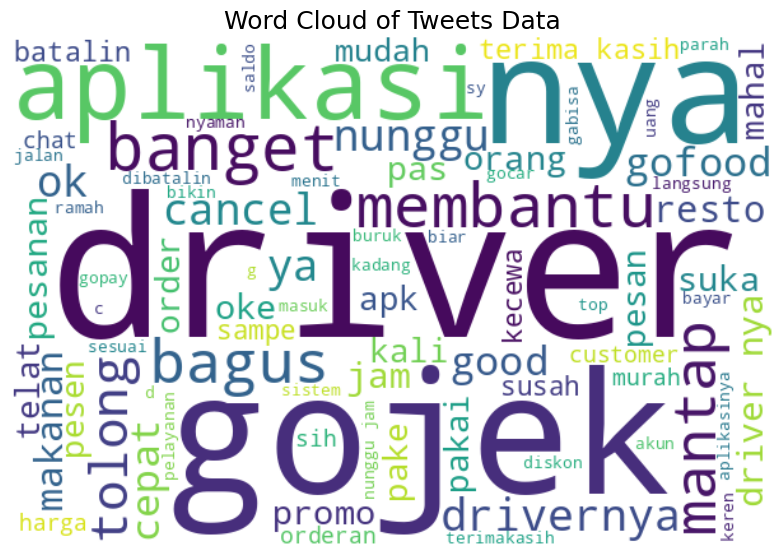

In [37]:
# Menggabungkan kata dalam setiap tweet dan kemudian menggabungkan semua tweet menjadi satu string besar
# Changed the list comprehension to join the list of words into a string first
# Corrected the variable name to `df` to use the processed dataframe
# Ensure that 'tweet' is a string and handle potential non-string values
list_words = ' '.join([' '.join(str(tweet).split()) for tweet in df['text_StopWord'] if isinstance(tweet, (str, list))])

# Membuat objek WordCloud dengan parameter tertentu
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)

# Membuat gambar dan sumbu untuk menampilkan word cloud
fig, ax = plt.subplots(figsize=(8, 6))

# Menetapkan judul untuk word cloud
ax.set_title('Word Cloud of Tweets Data', fontsize=18)

# Menonaktifkan grid pada sumbu
ax.grid(False)

# Menampilkan word cloud dalam gambar
ax.imshow(wordcloud, interpolation='bilinear')

# Mengatur layout gambar
fig.tight_layout(pad=0)

# Menyembunyikan sumbu
ax.axis('off')

# Menampilkan word cloud
plt.show()

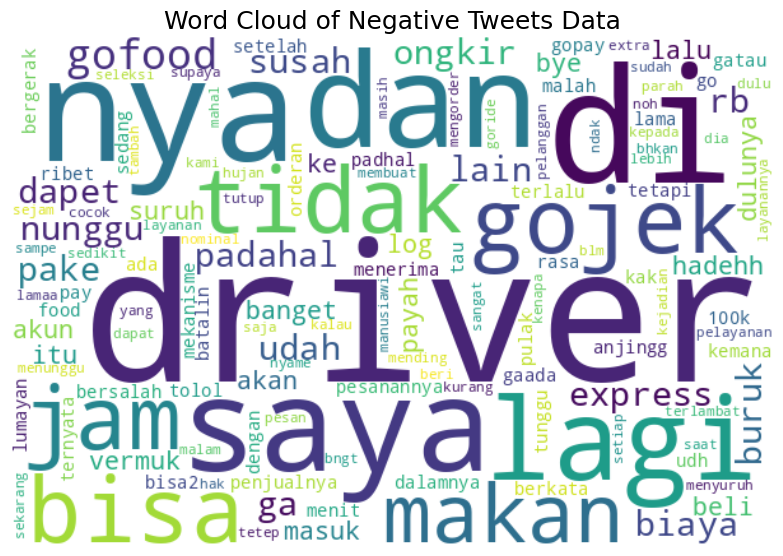

In [38]:
# Gabungkan semua tweet negatif menjadi satu string besar
list_words = ' '.join(negative_tweets['text_Clean'].astype(str).tolist())

# Membuat objek WordCloud dengan parameter tertentu
wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)

# Membuat gambar dan sumbu untuk menampilkan word cloud
fig, ax = plt.subplots(figsize=(8, 6))

# Menetapkan judul untuk word cloud
ax.set_title('Word Cloud of Negative Tweets Data', fontsize=18)

# Menonaktifkan grid pada sumbu
ax.grid(False)

# Menampilkan word cloud dalam gambar
ax.imshow(wordcloud, interpolation='bilinear')

# Mengatur layout gambar
fig.tight_layout(pad=0)

# Menyembunyikan sumbu
ax.axis('off')

# Menampilkan word cloud
plt.show()


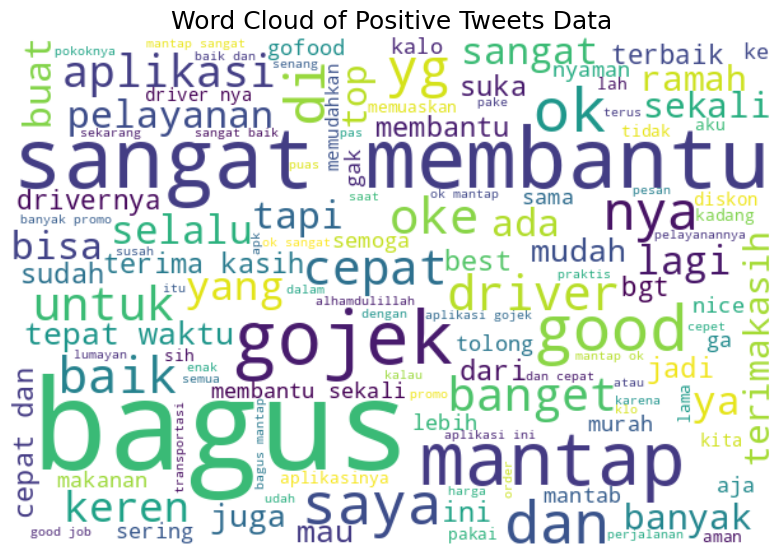

In [39]:
list_words = ' '.join(positive_tweets['text_Clean'].astype(str).tolist())
# Membuat objek WordCloud dengan parameter tertentu
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)

# Membuat gambar dan sumbu untuk menampilkan word cloud
fig, ax = plt.subplots(figsize=(8, 6))

# Menetapkan judul untuk word cloud
ax.set_title('Word Cloud of Positive Tweets Data', fontsize=18)

# Menonaktifkan grid pada sumbu
ax.grid(False)

# Menampilkan word cloud dalam gambar
ax.imshow(wordcloud, interpolation='bilinear')

# Mengatur layout gambar
fig.tight_layout(pad=0)

# Menyembunyikan sumbu
ax.axis('off')

# Menampilkan word cloud
plt.show()

**Visualisasi**

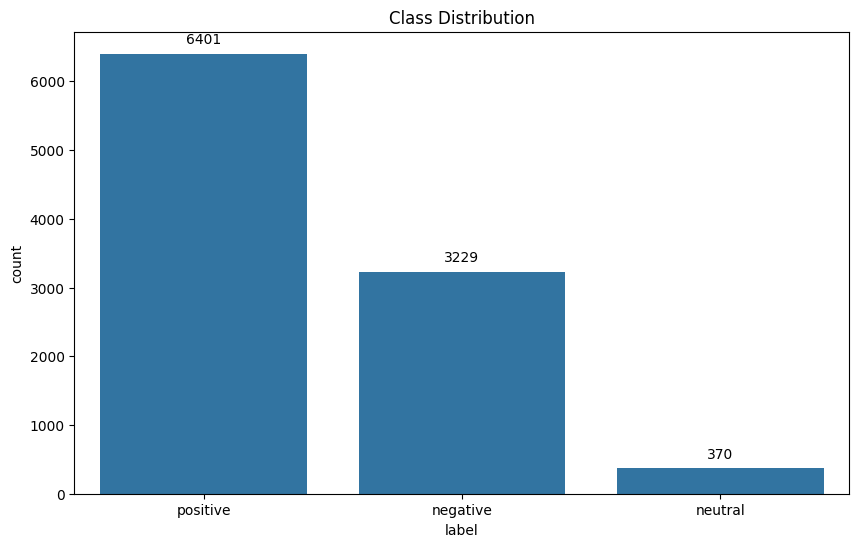

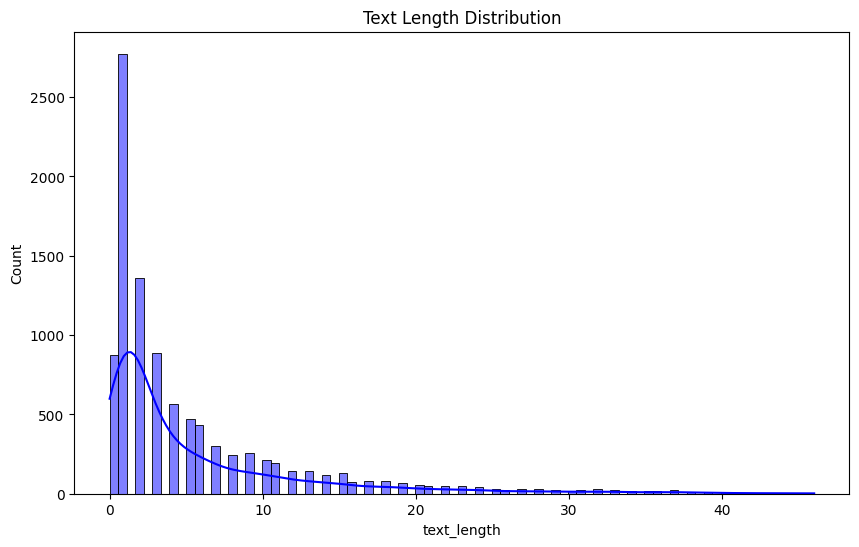

/tmp/ipykernel_630/802625936.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='jumlah', y='word', data=word_frequencies, palette="Blues_d")


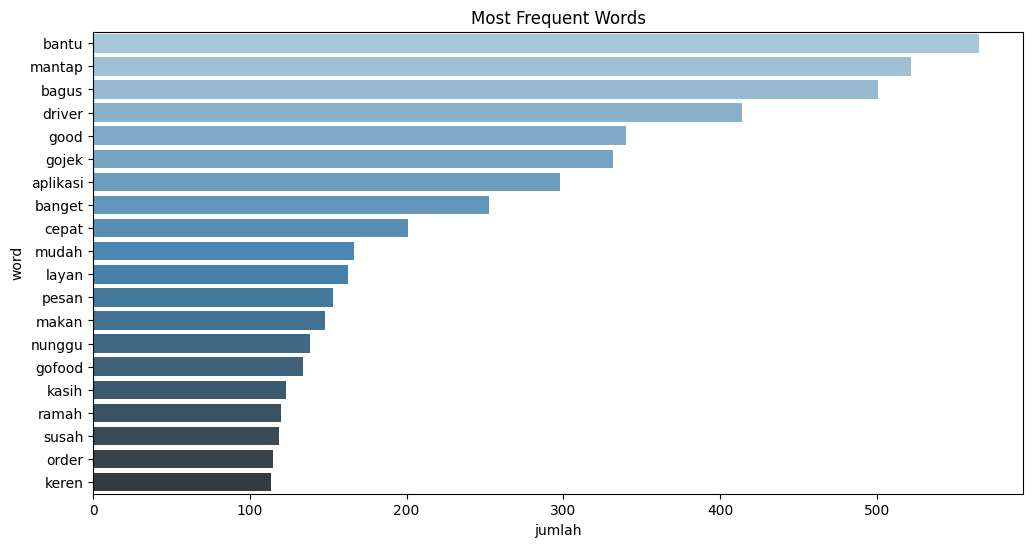

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. **Class Distribution Plot**
plt.figure(figsize=(10, 6))
# Replace 'clean_df' with 'df' and 'polarity' with 'label'
class_dist_plot = sns.countplot(x='label', data=df)
plt.title('Class Distribution')

# Add counts above the bars on the plot
for p in class_dist_plot.patches:
    class_dist_plot.annotate(format(p.get_height(), '.0f'),
                              (p.get_x() + p.get_width() / 2., p.get_height()),
                              ha='center', va='center',
                              xytext=(0, 10),
                              textcoords='offset points')

plt.show()

# 2. **Text Length Distribution Plot**
plt.figure(figsize=(10, 6))
# Replace 'clean_df' with 'df' and 'text_akhir' with 'text_String'
df['text_length'] = df['text_String'].apply(lambda x: len(str(x).split())) # Calculate text length, ensuring x is a string
sns.histplot(df['text_length'], kde=True, color='blue')  # Added KDE for better view of distribution
plt.title('Text Length Distribution')
plt.show()

# 3. **Most Frequent Words Visualization**
plt.figure(figsize=(12, 6))

# We will limit the number of words to consider to speed up the process.
vectorizer = TfidfVectorizer(max_features=1000)  # Limit to top 1000 features for better performance
# Replace 'text_akhir' with 'text_String'
X = vectorizer.fit_transform(df['text_String'])

# Convert the sparse matrix to dense matrix
tfidf_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

# Sum the tf-idf values for each word across all tweets
word_frequencies = tfidf_df.sum(axis=0).reset_index(name='jumlah')
word_frequencies.columns = ['word', 'jumlah']  # Rename columns for better clarity

# Sort the words based on their frequency
word_frequencies = word_frequencies.sort_values('jumlah', ascending=False).head(20)

# Plot the most frequent words
sns.barplot(x='jumlah', y='word', data=word_frequencies, palette="Blues_d")
plt.title('Most Frequent Words')
plt.show()

**Menyimpan Hasil PreProcessing Text**

In [41]:
# Simpan hasilnya
df.to_csv('hasil_Preprocessing_gojek.csv',index= False)